In [5]:
import numpy as np
ga_data = np.load('./1L10_TEST8_nsga_II_results.npy')

In [6]:
import numpy as np
def read_cebaf(filename):
    data = np.load(filename)
    nentries = int(data.shape[0]/3)
    heat = data[0:nentries]
    trip = data[nentries:2*nentries]
    alpha = data[2*nentries:3*nentries] 
    return heat,trip,alpha

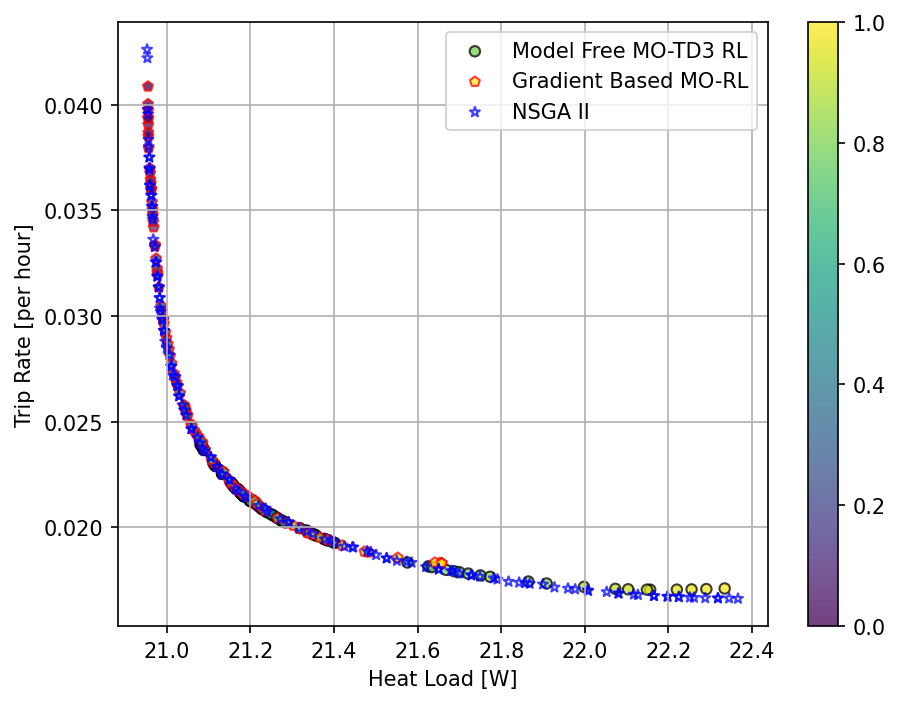

In [79]:
# mf_heat, mf_trip, mf_alpha = read_cebaf('../drivers/results'
#                +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash4cc092e_results_20240731-145258'
#                +'/inference_results_steps250000.npy')
mf_heat, mf_trip, mf_alpha = read_cebaf('../drivers/results'
               +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash9e9af1c_results_20240731-191418'
               +'/inference_results_steps200000.npy')

mb_heat, mb_trip, mb_alpha = read_cebaf('../drivers/results'
               +'/index0_agent_MO-KerasMB-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC-TF_hasha5517e3_results_20240731-163838'
               +'/inference_results_steps0.npy')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(dpi=150)
plt.scatter(mf_heat, mf_trip, c=mf_alpha, marker='o', s=25, edgecolors='black', alpha=0.75, label="Model Free MO-TD3 RL")
plt.scatter(mb_heat, mb_trip, c=mb_alpha, marker='p', s=25, edgecolors='red', alpha=0.75, label="Gradient Based MO-RL")
plt.scatter(ga_data[:,0], ga_data[:,1], marker='*', s=25, facecolors='none', alpha=0.75, edgecolors='blue', label="NSGA II")
plt.legend()
plt.grid()
plt.xlabel('Heat Load [W]')
plt.ylabel('Trip Rate [per hour]');
plt.colorbar()
plt.tight_layout()
plt.savefig('cebaf_mo.jpg')

In [58]:
data = np.load('1L10_TEST8_nsga_II_results.npy')
print(data.shape)

(128, 2)


(190,)
(190,)
(190,)


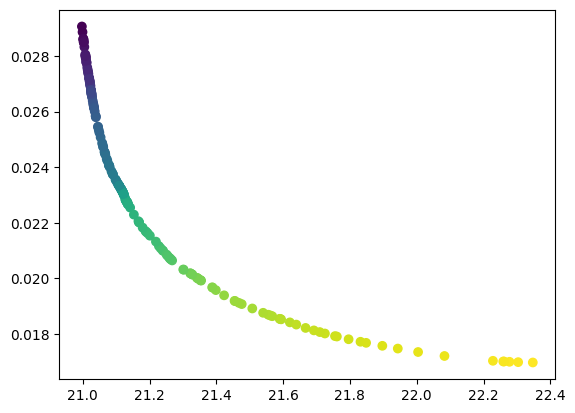

In [38]:
import numpy as np
data = np.load('../drivers/results'
               +'/index0_agent_MO-KerasTD3-v0_buf_cfg_bsize_cfg_env_PACES-MO-CEBAF-8D-VEC_hash4cc092e_results_20240731-145258'
               +'/inference_results_steps250000.npy')
nentries = int(data.shape[0]/3)
heat = data[0:nentries]
trip = data[nentries:2*nentries]
alpha = data[2*nentries:3*nentries]
print(heat.shape)
print(trip.shape)
print(alpha.shape)
# print(data[0:nentries])
# data = data.reshape(nentries,-1)
# print(data.shape)
# print(data[:,0])
import matplotlib.pyplot as plt
plt.scatter(heat, trip, c=alpha, marker='o')